In [3]:
from langchain_ollama import ChatOllama
from langchain_community.tools import TavilySearchResults
from langchain_core.tools import tool
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import START

from datetime import datetime
from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv
_=load_dotenv()





In [4]:
# bruker lokalt installert Ollama modell
llm = ChatOllama(
    model="llama3.1",
    temperature=0.7,
)


In [5]:
# Tavility søke verktøy
tavility_search_results = TavilySearchResults(max_results=2)

# henter dagens dato

@tool
def get_current_date() -> str:
    """Returns the current date in YYYY-MM-DD format."""
    return f"Today's date is {datetime.now().strftime('%Y-%m-%d')}"

/var/folders/hj/x4wfx_bs4q34dvmpj96hnctm0000gn/T/ipykernel_36165/301464130.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavility_search_results = TavilySearchResults(max_results=2)


In [25]:
tools = [tavility_search_results, get_current_date]


In [7]:
llm_with_tools = llm.bind_tools(tools)

In [8]:
# Uten reducer: overstyrer hele listen
#state["messages"] = [new_message]  # ❌ gamle meldinger er borte

# Med add_messages reducer: slår sammen intelligent  
#state["messages"] = old_messages + [new_message]  # ✅ bevarer historikk


# lager tilstand for agenten, som inkluderer en liste over meldinger
class State(TypedDict):
    """State of the agent."""
    messages: Annotated[list, add_messages]

In [9]:
# definerer en node
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [10]:
graph_builder = StateGraph(State)

In [11]:
graph_builder.add_node("chatbot", chatbot)

In [12]:
# Legger til tools som node og legger til graph
tool_node=ToolNode(tools=tools)
graph_builder.add_node("tool_node", tool_node)

In [13]:
## kun kjøre en gang
graph_builder.add_conditional_edges(
    "chatbot", 
    tools_condition,
    {"tools": "tool_node", "__end__": "__end__"}
)

In [14]:
graph_builder.add_edge("tool_node", "chatbot")

In [15]:
graph_builder.add_edge(START, "chatbot")

In [16]:
# kompilerer graphen til en agent
graph = graph_builder.compile()


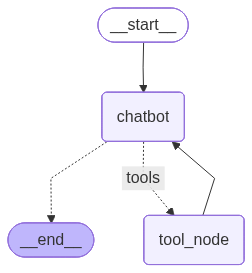

In [17]:
from IPython.display import display, Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not render graph:", e)


In [26]:
from IPython.display import Markdown, display

def render_markdown(md_string):
    display(Markdown(md_string))

def process_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()
    return message

def process_query(query, config=None):
    inputs = {"messages": [("user", query)]}
    message = process_stream(graph.stream(inputs, config, stream_mode="values"))
    render_markdown(f"## Answer:\n{message.content}")

In [27]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

### Legger inn intertuprt Human in the loop

In [29]:
# kompilerer graph med en checkpoint
graph = graph_builder.compile(checkpointer=memory,
                              interrupt_before=["tool_node"])

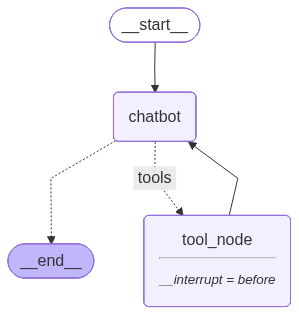

In [31]:
from IPython.display import display, Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not render graph:", e)

In [32]:
user_input = "Hvordan er været i Oslo i dag?"
config={"configurable": {"thread_id": "1"}}

events = graph.stream({"messages": [("user", user_input)]}, config, stream_mode="values")

for event in events:
    if "messages" in event:
        message = event["messages"][-1]
        message.pretty_print()

================================ Human Message =================================

Hvordan er været i Oslo i dag?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (49a81485-14cb-4eeb-8435-d4a07e7cf1f5)
 Call ID: 49a81485-14cb-4eeb-8435-d4a07e7cf1f5
  Args:
    query: været i Oslo i dag


### Hva er neste steg ?

In [33]:
snapshot = graph.get_state(config)
print(snapshot.next)

('tool_node',)


In [37]:
events = graph.stream(None, config, stream_mode="values")

for event in events:
    if "messages" in event:
        message = event["messages"][-1]
        message.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (49a81485-14cb-4eeb-8435-d4a07e7cf1f5)
 Call ID: 49a81485-14cb-4eeb-8435-d4a07e7cf1f5
  Args:
    query: været i Oslo i dag
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Yr - Oslo V - Langtidsvarsel", "url": "https://www.yr.no/nb/v%C3%A6rvarsel/daglig-tabell/1-73867/Norge/Oslo/Oslo/Oslo%20V", "content": "Gå til innholdet\n\nEt samarbeid mellom NRK og Meteorologisk institutt\n\n# Oslo V\n\nAnnen kulturdetalj (Oslo), 4 moh.\n\nDet ser ut til at du bruker en gammel nettleser. For å få tilgang til alt av innhold på Yr anbefaler vi at du oppdaterer nettleseren din.\n\nDet ser ut til at JavaScript er skrudd av i nettleseren din. For å få tilgang til alt av innhold på Yr anbefaler vi at du skrur på JavaScript.\n\n## Været nå\n\nskyet\n\nTemperatur15°\n\n15°\n\nFøles som 15°\n\nNedbør 0mm\n\n2 

In [51]:
last_message = snapshot.values["messages"][-1]
print(" Orginal tool call result:", last_message.tool_calls)
print(" Tool call message id:", last_message.id)

 Orginal tool call result: [{'name': 'tavily_search_results_json', 'args': {'query': 'været i Oslo i dag'}, 'id': '49a81485-14cb-4eeb-8435-d4a07e7cf1f5', 'type': 'tool_call'}]
 Tool call message id: lc_run--019e682e-9188-75c0-b6a6-036f0c1cbfd5-0


In [52]:
from langchain_core.messages import AIMessage
new_tool_call = last_message.tool_calls[0].copy()
new_tool_call["args"] = {"query": "Hva er temperaturen i Bærum nå idag?"}

new_message = AIMessage(
    content=last_message.content,
    tool_calls=[new_tool_call],
    id=last_message.id
)

print ("new tool call:", new_tool_call)
print("new tool message id:", new_message.id)

new tool call: {'name': 'tavily_search_results_json', 'args': {'query': 'Hva er temperaturen i Bærum nå idag?'}, 'id': '49a81485-14cb-4eeb-8435-d4a07e7cf1f5', 'type': 'tool_call'}
new tool message id: lc_run--019e682e-9188-75c0-b6a6-036f0c1cbfd5-0


In [56]:
graph.update_state(config, {"messages": [new_message]})
print("State updated with new message containing modified tool call.")
result = graph.get_state(config).values["messages"][-1]
print(f"Type of last message: {type(result)}")
print(f"Tool calls: {result.tool_calls}")
print(f"Full message: {result}")

State updated with new message containing modified tool call.
Type of last message: <class 'langchain_core.messages.ai.AIMessage'>
Tool calls: [{'name': 'tavily_search_results_json', 'args': {'query': 'Hva er temperaturen i Bærum nå idag?'}, 'id': '49a81485-14cb-4eeb-8435-d4a07e7cf1f5', 'type': 'tool_call'}]
Full message: content='' additional_kwargs={} response_metadata={} id='e6e00bc7-8815-4325-b019-7aaf5c528a42' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Hva er temperaturen i Bærum nå idag?'}, 'id': '49a81485-14cb-4eeb-8435-d4a07e7cf1f5', 'type': 'tool_call'}] invalid_tool_calls=[]


In [58]:

# LØSNING: Ikke sett id på den nye meldingen
# Slik blir den lagt til som ny melding istedenfor å merges med den gamle

new_message_without_id = AIMessage(
    content=last_message.content,
    tool_calls=[new_tool_call]
    # Merk: Ikke sett id her!
)

graph.update_state(config, {"messages": [new_message_without_id]})
print("State updated with new message (without id - added as new message)")
result = graph.get_state(config).values["messages"][-1]
print(f"Tool calls: {result.tool_calls}")
print(f"Message count: {len(graph.get_state(config).values['messages'])}")

State updated with new message (without id - added as new message)
Tool calls: [{'name': 'tavily_search_results_json', 'args': {'query': 'Hva er temperaturen i Bærum nå idag?'}, 'id': '49a81485-14cb-4eeb-8435-d4a07e7cf1f5', 'type': 'tool_call'}]
Message count: 7


In [59]:
event = graph.stream(None, config, stream_mode="values")
for event in event:
    if "messages" in event:
        message = event["messages"][-1]
        message.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (49a81485-14cb-4eeb-8435-d4a07e7cf1f5)
 Call ID: 49a81485-14cb-4eeb-8435-d4a07e7cf1f5
  Args:
    query: Hva er temperaturen i Bærum nå idag?
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Været i Norge i mai 2026: temperatur og klima", "url": "https://no.climate-data.org/europa/norge-38/c/mai-5", "content": "|  | Januar | februar | mars | april | mai | juni | juli | august | september | oktober | november | desember |\n ---  ---  ---  ---  ---  --- \n| Gjennomsnittstemperatur °C | -5.1 | -4.2 | -0.6 | 5 | 10.7 | 14.7 | 17.4 | 15.9 | 12.1 | 6.3 | 1.8 | -3.1 |\n| Min. temperatur °C | -7.5 | -7.1 | -4.3 | 0.5 | 5.9 | 10.3 | 13.5 | 12.5 | 9.1 | 4.1 | 0 | -5.4 |\n| Maks. temperatur °C | -2.8 | -1.2 | 3.2 | 9.4 | 15 | 18.8 | 21.1 | 19.3 | 15.2 | 8.5 | 3.5 | -1.1 |\n| Nedbør mm | 79 | 59 | 56 